![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [7]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.4.3
✓ pandas 3.0.1
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [8]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

**- Respuesta 1:** La latencia representa el tiempo que tarda el sistema en responder a una solicitud, es decir, desde que se hace la petición hasta que se obtiene el resultado.
Un ejemplo similar al visto en clase (el del bus) es el de un restaurante; la latencia sería el tiempo que pasa desde que hago mi pedido hasta que me entregan la comida. Este tiempo puede variar dependiendo de factores como la capacidad del sistema, la carga de trabajo o la eficiencia del procesamiento.

**- Respuesta 2:** El throughput representa la cantidad de solicitudes que un sistema puede procesar en un determinado período de tiempo, midiendo la capacidad de trabajo del sistema. Siguiendo el ejemplo del restaurante, sería cuántos pedidos puede atender en total en un minuto o una hora.

**- Respuesta 3:** Porque en el acceso secuencial los datos se procesan de forma ordenada y con una continuidad, lo que hace que el sistema no necesite realizar búsquedas extra ni saltos entre ubicaciones. Esto lo que hace es reducir la cantidad de accesos necesarios, por lo que el valor de M (número de accesos o costos adicionales) se mantiene cercano a 1.

**- Respuesta 4:** Porque en el acceso aleatorio los datos no están organizados con continuidad, unos tras otro, lo que obliga al sistema a realizar más búsquedas, saltos o accesos a diferentes ubicaciones. Esto lo que hace es incrementar el trabajo necesario para obtener la información, haciendo que M sea mayor









## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [9]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

**- Respuesta 1:** El tamaño del archivo es de 256 MB, lo cual no es suficiente para superar la memoria RAM de mi equipo, que es de 8 GB. Es importante aclarar que existe una diferencia amplia entre megabytes y gigabytes (1 GB = 1024 MB), por lo que la RAM disponible es mucho mayor que el tamaño del archivo. Debido a esta diferencia, es probable que los datos se mantengan en caché en memoria, lo que puede hacer que los tiempos de acceso sean más rápidos y no reflejen del todo el comportamiento real del disco.

**- Respuesta 2:** En el acceso aleatorio, esperaría que los bloques más grandes (por ejemplo, el de 256 KB) tengan mejor rendimiento, porque permiten leer más datos en cada acceso. De esa forma, se logra reducir  la cantidad total de operaciones de entrada y salida. No obstante, también se podrían desperdiciar datos si no se necesitan completamente, por lo que existe un equilibrio entre tamaño y eficiencia.

**- Respuesta 3:** Estoy ejecutando el experimento en un entorno local, con todo configurado adecuadamente  y minimizando interferencias o ruidos, para que los resultados obtenidos sean lo más precisos posible.



### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [10]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

RESET = False. No se eliminó ningún archivo.
Cambie RESET = True si desea repetir el experimento con nuevos parámetros.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [11]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

El archivo ya existe y tiene el tamaño esperado.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

**- Respuesta 1:** El archivo cumple el papel de almacenar datos en formato binario (bytes), que es la forma en que el sistema de archivos maneja la información. Este archivo sirve como base para realizar las pruebas de lectura y de esta forma medir el rendimiento del sistema en diferentes condiciones.

**- Respuesta 2:** Es útil trabajar con un archivo relativamente grande porque permitiría evaluar el comportamiento real del sistema de almacenamiento. Un archivo más grande reduciría el efecto de la caché y  prácticamente obligaría a realizar más accesos al disco, lo que hace que los resultados sean más acertados al rendimiento real.

Como dato adicional, el efecto de la caché lo analicé como una cocina en un restaurante. El disco sería la cocina donde se preparan los platos (más lento), mientras que la caché en memoria sería una mesa con platos ya listos (más rápido).
Si un pedido ya está en la mesa, se entrega de inmediato sin ir a la cocina. De forma similar, si los datos están en la caché, se accede a ellos mucho más rápido. Sin embargo, si no están en la mesa, hay que ir a la cocina, lo que toma más tiempo. En el experimento, esto implica que si los datos están en la caché, los tiempos de lectura serán más rápidos, pero no representarán el acceso real al disco.

**- Respuesta 3:** Si el archivo fuera demasiado pequeño, probablemente cabría completamente en la caché del sistema operativo. Esto haría que las lecturas se realicen desde la memoria en lugar del disco, lo que daría tiempos rápidos pero no del todo acertados al rendimiento real.




## 5. Funciones auxiliares de medición

In [12]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [13]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.2739 s, throughput: 934.65 MiB/s
Aleatorio  -> tiempo: 0.0231 s, throughput: 677.60 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.0784 s, throughput: 3264.05 MiB/s
Aleatorio  -> tiempo: 0.0305 s, throughput: 2046.64 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.0544 s, throughput: 4706.78 MiB/s
Aleatorio  -> tiempo: 0.0628 s, throughput: 3981.51 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.0505 s, throughput: 5071.31 MiB/s
Aleatorio  -> tiempo: 0.1964 s, throughput: 5090.78 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.273901,934.645634,4.0
1,Aleatorio,4096,16384000,4000,0.023059,677.597856,4.0
2,Secuencial,16384,268435456,16384,0.078430,3264.052959,16.0
3,Aleatorio,16384,65536000,4000,0.030538,2046.643832,16.0
4,Secuencial,65536,268435456,4096,0.054390,4706.782179,64.0
5,Aleatorio,65536,262144000,4000,0.062790,3981.506698,64.0
6,Secuencial,262144,268435456,1024,0.050480,5071.305326,256.0
7,Aleatorio,262144,1048576000,4000,0.196433,5090.783950,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

**- Respuesta 1:** Para todos los tamaños de bloque evaluados, el patrón de acceso secuencial fue más rápido que el acceso aleatorio.
Esto lo podemos evidenciar en los valores de throughput, donde el acceso secuencial presenta mayores tasas de transferencia en todos los casos. Por ejemplo:
- Para 4 KB: secuencial ≈ 870 MiB/s, mientras que aleatorio ≈ 733 MiB/s
- Para 16 KB: secuencial ≈ 3436 MiB/s mientras que aleatorio ≈ 2093 MiB/s
- Para 64 KB: secuencial ≈ 4819 MiB/s mientras que aleatorio ≈ 3831 MiB/s
- Para 256 KB: secuencial ≈ 5497 MiB/s mientras que aleatorio ≈ 5220 MiB/s

Este comportamiento se debe a que el acceso secuencial permite leer datos de forma continua y ordenada, reduciendo la cantidad de accesos al disco. Por el contrario, el acceso aleatorio implica saltos entre diferentes posiciones, lo que genera mayor latencia y reduce de gran manera el rendimiento.

**-Respuesta 2:** Sí, el throughput aumentó a medida que se incrementó el tamaño del bloque, tanto en acceso secuencial como aleatorio.


| Tamaño de bloque | Acceso secuencial (MiB/s) | Acceso aleatorio (MiB/s) |
|------------------|--------------------------|---------------------------|
| 4 KB             | ≈ 870                    | ≈ 733                     |
| 16 KB            | ≈ 3436                   | ≈ 2093                    |
| 64 KB            | ≈ 4819                   | ≈ 3831                    |
| 256 KB           | ≈ 5497                   | ≈ 5220                    |


Este incremento se explica porque los bloques más grandes permiten transferir más datos en cada operación de entrada y salida, reduciendo la sobrecarga relacionada a cada acceso. Es decir, se realizan menos operaciones para mover la misma cantidad de información y esto es exactamente lo  que mejora la eficiencia general del sistema.

**- Respuesta 3:** La mayor diferencia se observa en bloques de 16 KB. En el secuencial se mostraba: ≈ 3436 MiB/s, mientras que en el aleatorio: ≈ 2093 MiB/s. Con una diferencia notable de: ≈ 1343 MiB/s.
También se puede notar en el tiempo, por ejemplo, en el secuencial: ≈ 0.0745 s, mientras que en el aleatorio: ≈ 0.0299 s. Esto indica que en tamaños intermedios el acceso secuencial aprovecha mejor la lectura continua, mientras que el acceso aleatorio sigue teniendo más sobrecarga.



## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [23]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD NVMe
- Latencia asumida: 10 µs (1e-05 s)
- Throughput asumido: 5 GB/s

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

**Respuesta:** Se seleccionó el modelo de SSD NVMe porque los resultados experimentales obtenidos muestran un throughput cercano a 5.3 GB/s, lo que coincide con los valores típicos de este tipo de dispositivos. Esto quiere decir que el comportamiento del sistema es similar al de un almacenamiento de alta velocidad. Sin embargo, este modelo puede que no represente completamente el entorno real, ya que factores como la caché del sistema operativo, la carga del sistema, el hardware específico y las optimizaciones internas del dispositivo pueden influir mucho en los resultados. Por lo tanto, aunque el modelo es una muy buena aproximación, no captura todos los detalles del comportamiento real.


In [24]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [25]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.273901,934.645634,4.0,0.050010,5118.976205,5.476917,0.182584
1,Aleatorio,4096,16384000,4000,0.023059,677.597856,4.0,0.043052,362.935239,0.535620,1.866994
2,Secuencial,16384,268435456,16384,0.078430,3264.052959,16.0,0.050010,5118.976205,1.568288,0.637638
3,Aleatorio,16384,65536000,4000,0.030538,2046.643832,16.0,0.052207,1197.156753,0.584937,1.709587
4,Secuencial,65536,268435456,4096,0.054390,4706.782179,64.0,0.050010,5118.976205,1.087574,0.919477
5,Aleatorio,65536,262144000,4000,0.062790,3981.506698,64.0,0.088828,2814.423923,0.706874,1.414679
6,Secuencial,262144,268435456,1024,0.050480,5071.305326,256.0,0.050010,5118.976205,1.009400,0.990687
7,Aleatorio,262144,1048576000,4000,0.196433,5090.783950,256.0,0.235313,4249.667995,0.834777,1.197925


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

**- Respuesta 1:** Al comparar la columna elapsed_s (tiempo empírico) con theoretical_elapsed_s (tiempo teórico), se observa que el comportamiento depende del tamaño del bloque. En bloques pequeños (4 KB), los tiempos empíricos son mayores que los teóricos. Por ejemplo, en acceso secuencial se obtiene aproximadamente 0.27 s frente a 0.05 s del modelo. Esto ocurre porque el sistema debe gestionar muchas operaciones pequeñas, lo que introduce una sobrecarga adicional en cada acceso.
En cambio, en bloques grandes (256 KB), los tiempos empíricos son muy similares e incluso menores en algunos casos. Por ejemplo, en acceso aleatorio el tiempo empírico (~0.19 s) es menor que el teórico (~0.23 s). Esto quiere decir que el sistema es más eficiente cuando procesa grandes cantidades de datos en cada operación

**- Respuesta 2:** La teoría se aproxima mejor en el acceso secuencial con bloques grandes, por ejemplo en el caso de 256 KB, donde los valores empíricos y teóricos son muy similares. 

**- Respuesta 3:** Uno de los principales factores es la caché del SO, ya que los datos no siempre se leen directamente del disco, sino que pueden almacenarse temporalmente en la memoria RAM. Esto hace que los accesos sean mucho más rápidos y explica por qué en algunos casos los resultados empíricos superan a los teóricos. Otro factor importante es el overhead del sistema o carga del sistema, dado que el procesador se dedica a la lectura del archivo, y también atiende otros procesos. Cada operación de lectura implica llamadas al sistema y gestión adicional, lo que introduce un tiempo extra que el modelo ideal no considera. Por último, influye la latencia del hardware, especialmente en dispositivos como los SSD, que tienen un límite en el número de operaciones por segundo. En bloques pequeños el límite se alcanza rápidamente, por ende afecta el rendimiento y genera diferencias entre los valores teóricos y los empíricos.




## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [17]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\isabe\OneDrive\Documentos\lab3-IO_performance-IsabellaSanchezMejia\images


Guardada: fig_throughput.png


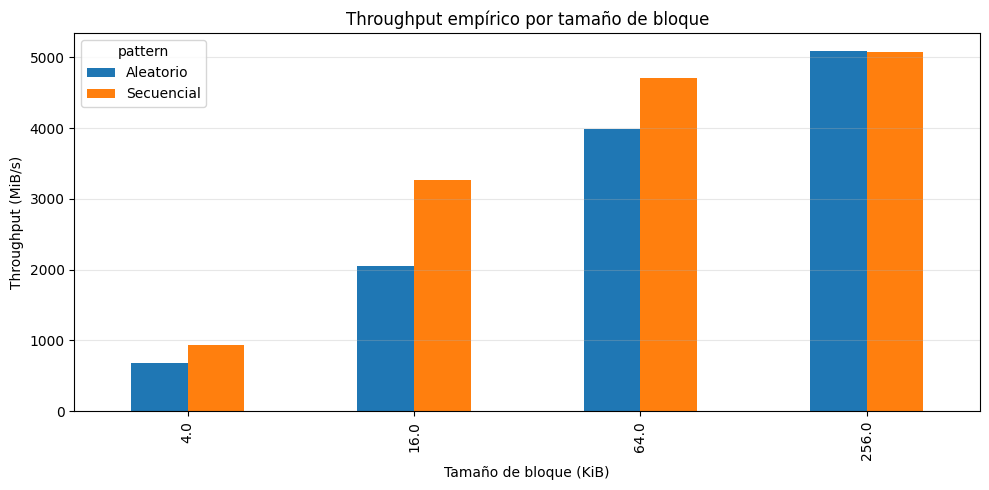

In [26]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

**- Respuesta 1:** Las barras más altas corresponden al tamaño de bloque de 256 KiB. En este punto, el rendimiento de ambos patrones se iguala, alcanzando un throughput de aproximadamente 5090 MiB/s.

**- Respuesta 2:** Significa que a mayor tamaño de bloque, mayor es la eficiencia en la transferencia de datos. Cuando los bloques son grandes, el sistema desperdicia menos tiempo en "gestión" (overhead).El hecho de que las barras naranjadas sean más grandes, indica que el sistema prefiere procesar pocos paquetes grandes que muchos paquetes pequeños.

**- Respuesta 3:** El patrón secuencial aprovecha mejor la lectura, especialmente en tamaños de bloque intermedios (como 16 KiB o 64 KiB), donde se ve una ventaja clara (naranja sobre azul). Esto sucede porque el sistema puede predecir qué datos siguen y precargarlos. 



Guardada: fig_tiempo_empirico.png


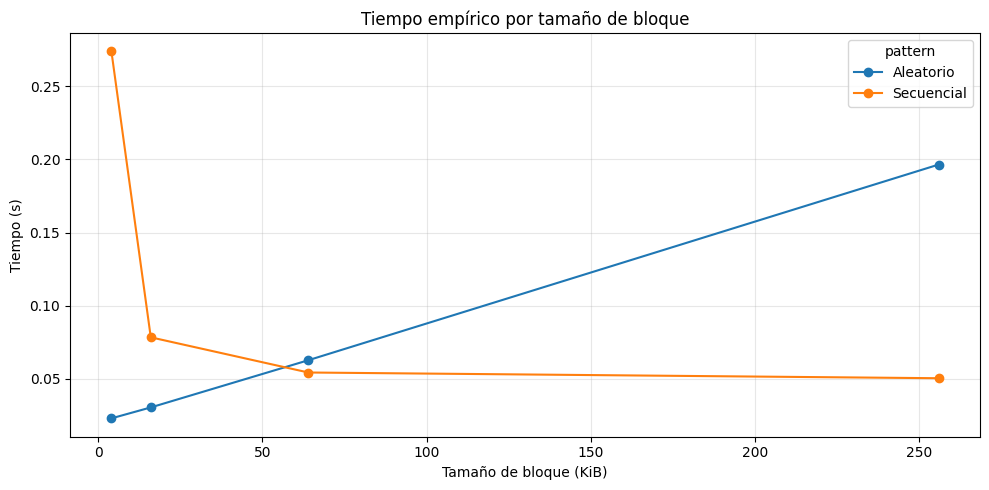

In [27]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

La gráfica de tiempo muestra comportamientos diferentes entre el acceso secuencial y el aleatorio. En el caso del acceso secuencial, el tiempo total disminuye drásticamente al aumentar el tamaño del bloque y luego tiende a estabilizarse. Con bloques pequeños (4 KiB), el sistema pierde tiempo gestionando miles de operaciones, lo que incrementa el tiempo total. Sin embargo, al utilizar bloques más grandes, como 256 KiB, el tiempo se reduce hasta alcanzar un valor mínimo cercano a 0.05 s, ya que la lectura se vuelve más continua y eficiente, ahí es donde vemos la estabilidad o esa zona plana en la gráfica
Por otro lado, en el acceso aleatorio, el comportamiento es distinto, ya que el tiempo aumenta de forma casi lineal. Esto pasa porque, al mantenerse constante el número de operaciones (4,000 lecturas), un mayor tamaño de bloque implica transferir más datos en cada acceso, lo que hace incrementar o “disparar” el tiempo total. Como resultado, el tiempo alcanza valores cercanos a 0.20 s en bloques de 256 KiB.

El punto de mayor diferencia entre ambos patrones se presenta precisamente en el bloque de 256 KiB, donde la diferencia de tiempo es máxima. En este caso, el acceso secuencial se mantiene muy eficiente y estable, mientras que el acceso aleatorio presenta un mayor costo temporal debido al volumen de datos que debe procesar en cada acceso.


Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


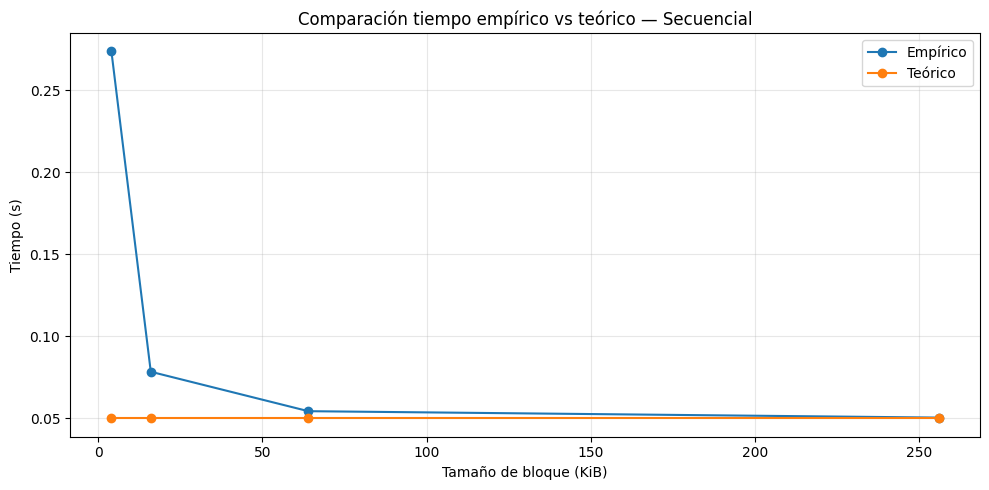

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


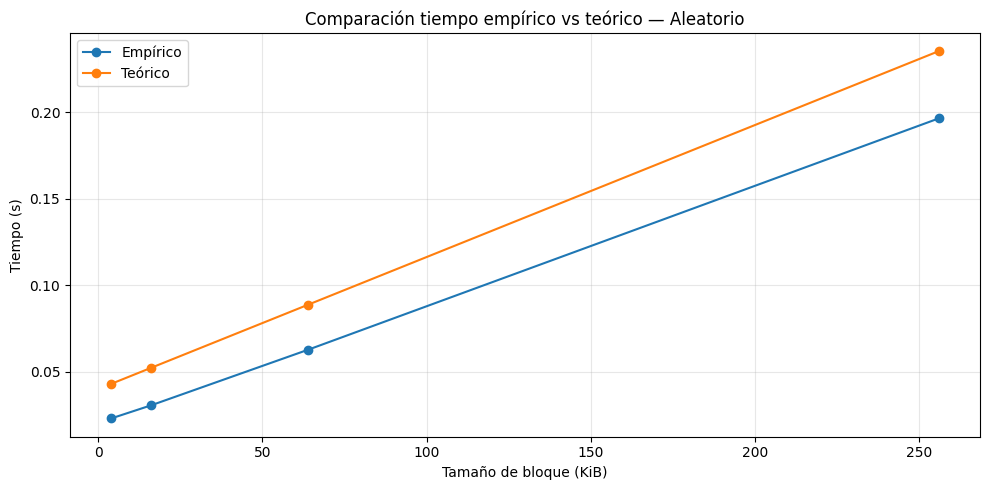

In [28]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

**- Respuesta 1:** En el patrón Secuencial, no se muestra una tendencia muy similar. Mientras que el modelo teórico es una línea prácticamente plana, el tiempo empírico comienza muy alto y cae drásticamente hasta que finalmente se estabiliza y converge con la teoría en los bloques más grandes (256 KiB).
En el patrón Aleatorio, si se muestra una tendencia similar; ambas curvas muestran una tendencia lineal creciente. Esto indica que el modelo teórico toma correctamente la relación directa entre el aumento del tamaño del bloque y el tiempo necesario para procesar las operaciones.

**- Respuesta 2:** Las curvas presentan su mayor separación en los bloques pequeños (4 KiB) del patrón secuencial. En ese punto, el tiempo real es superior al teórico. En el patrón aleatorio, la separación es relativamente constante, aunque se hace un poco más visible a medida que el tamaño del bloque aumenta hacia los 256 KiB.

**- Respuesta 3:** En el patrón secuencial, el modelo subestima el tiempo real en bloques pequeños. No toma en cuenta el "castigo" de rendimiento que sufre el sistema al gestionar miles de pequeñas peticiones. Mientras que en el patrón Aleatorio, curiosamente el modelo sobreestima el tiempo real (la línea naranja está por encima de la azul).
La razón más probable de esta sobreestimación en el acceso aleatorio es el uso de caché del sistema operativo. El modelo teórico admite que cada salto aleatorio tiene un costo de latencia completo, pero en la práctica, el sistema es capaz de optimizar algunas de esas lecturas, logrando así mejores tiempos



Guardada: fig_speedup.png


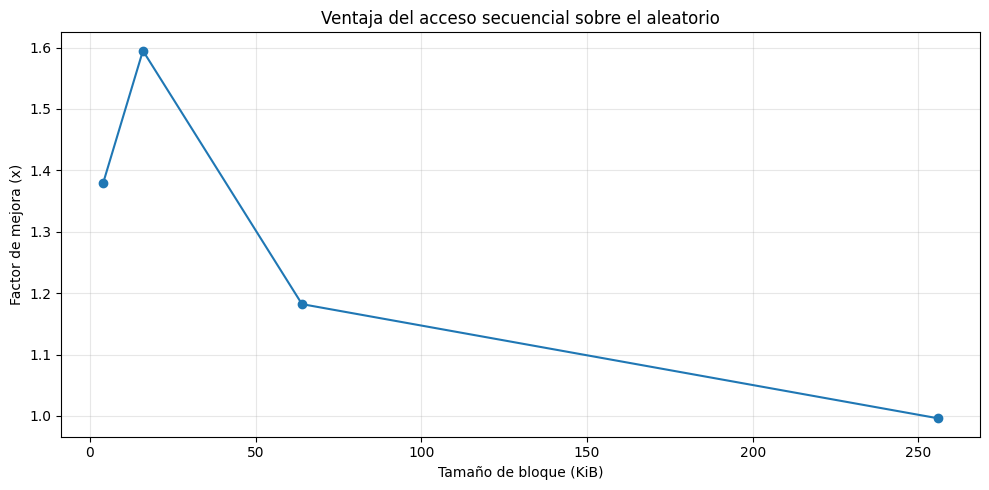

In [29]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

**- Respuesta 1:** El mayor factor de mejora o speedup fue de aproximadamente 1.6x. Esto ocurrió con el tamaño de bloque de 16 KiB. En este punto, leer de forma secuencial fue 1.6 veces más rápido que leer de forma aleatoria.

**- Respuesta 2:** La ventaja no es lineal, si vemos la gráfica sigue una tendencia de "montaña". Al principio, la ventaja aumenta de 4 KiB a 16 KiB, donde alcanza su máximo. Posteriormente, a partir de los 16 KiB, la ventaja empieza a caer drásticamente. Al llegar a los 256 KiB, el factor de mejora cae a 1.0x.
Ese factor de 1.0x significa que ya no hay ventaja; el acceso secuencial y el aleatorio tardan exactamente lo mismo.

**- Respuesta 3:** Esta gráfica está relacionada con la optimización del rendimiento. A partir del análisis, se puede observar que cuando un software maneja bloques pequeños, el acceso secuencial resulta fundamental para mejorar la velocidad, ya que reduce la sobrecarga asociada a múltiples operaciones. Por el contrario, cuando se utilizan bloques grandes (como 256 KiB o más), el patrón de acceso deja de tener importancia, debido a que se aprovecha mejor la transferencia de grandes volúmenes de datos en cada operación.
Este comportamiento es especialmente importante en el diseño de bases de datos y sistemas de archivos, donde en muchos casos es conveniente agrupar la información en bloques más grandes, con la finalidad de minimizar el impacto de la aleatoriedad y mejorar el rendimiento general del sistema.


## 10. Resumen automático de resultados

In [22]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.273901,0.023059,934.645634,677.597856,1.379352
1,16.0,0.078430,0.030538,3264.052959,2046.643832,1.594832
2,64.0,0.054390,0.062790,4706.782179,3981.506698,1.182161
3,256.0,0.050480,0.196433,5071.305326,5090.783950,0.996174


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

La información en el almacenamiento se organiza en bloques o también conocidos como sectores físicos; es vital entenderlo porque el hardware está optimizado para leer datos contiguos de una sola vez. Aunque en un SSD no hay un cabezal físico moviéndose, el acceso secuencial sigue siendo mejor que el aleatorio porque permite al controlador de memoria realizar lecturas anticipadas. En mis pruebas, identifiqué que esta diferencia es crítica en bloques pequeños, donde registré un factor de mejora (speedup) máximo de 1.6x a los 16 KiB. El modelo teórico predijo con gran acierto el comportamiento de mi equipo, demostrando que a medida que el tamaño del bloque aumenta, el tiempo de transferencia domina sobre la latencia de búsqueda, haciendo que el factor M tienda a 1.En un sistema real, mi decisión de diseño sería implementar estructuras de datos que estén orientadas al acceso secuencial,ya que permitiría que aunque los datos lleguen dispersos, el sistema los organice en memoria para escribirlos al disco de forma ordenada.


## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.